In [1]:
import onnxruntime

session = onnxruntime.InferenceSession('yolox_s_10.onnx')

In [2]:
import cv2
image = cv2.imread('example/photo3.png')
print(image.shape)

(512, 640, 3)


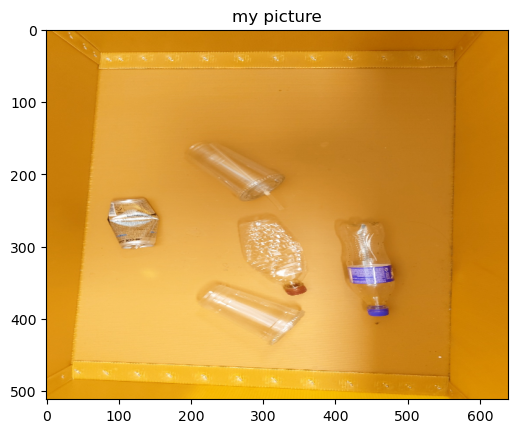

In [3]:
from matplotlib import pyplot as plt
plt.imshow(image)
plt.title('my picture')
plt.show()

In [4]:
import numpy as np
import torch
def preproc(img, input_size, swap=(2, 0, 1)):
    if len(img.shape) == 3:
        padded_img = np.ones((input_size[0], input_size[1], 3), dtype=np.uint8) * 114
    else:
        padded_img = np.ones(input_size, dtype=np.uint8) * 114

    r = min(input_size[0] / img.shape[0], input_size[1] / img.shape[1])
    resized_img = cv2.resize(
        img,
        (int(img.shape[1] * r), int(img.shape[0] * r)),
        interpolation=cv2.INTER_LINEAR,
    ).astype(np.uint8)
    padded_img[: int(img.shape[0] * r), : int(img.shape[1] * r)] = resized_img

    padded_img = padded_img.transpose(swap)
    padded_img = np.ascontiguousarray(padded_img, dtype=np.float32)
    return padded_img, r

In [5]:
img, _=preproc(image, (512, 640))
img

array([[[198., 202., 206., ..., 200., 201., 201.],
        [200., 201., 204., ..., 200., 200., 200.],
        [202., 201., 201., ..., 199., 198., 200.],
        ...,
        [221., 222., 223., ..., 224., 223., 221.],
        [222., 223., 223., ..., 222., 222., 222.],
        [223., 222., 221., ..., 223., 222., 222.]],

       [[128., 128., 128., ..., 123., 124., 124.],
        [132., 130., 129., ..., 123., 123., 122.],
        [130., 130., 131., ..., 122., 121., 123.],
        ...,
        [149., 150., 152., ..., 146., 144., 143.],
        [150., 151., 151., ..., 145., 145., 144.],
        [151., 150., 149., ..., 146., 145., 146.]],

       [[  5.,   4.,   5., ...,   1.,   2.,   1.],
        [  9.,   6.,   4., ...,   1.,   1.,   0.],
        [  7.,   6.,   5., ...,   0.,   0.,   1.],
        ...,
        [  7.,   8.,  10., ...,   3.,   1.,   0.],
        [  8.,   9.,   9., ...,   0.,   0.,   1.],
        [  9.,   8.,   7., ...,   0.,   0.,   0.]]], dtype=float32)

In [6]:
img = torch.from_numpy(img).unsqueeze(0)
img = img.float()

In [7]:
img

tensor([[[[198., 202., 206.,  ..., 200., 201., 201.],
          [200., 201., 204.,  ..., 200., 200., 200.],
          [202., 201., 201.,  ..., 199., 198., 200.],
          ...,
          [221., 222., 223.,  ..., 224., 223., 221.],
          [222., 223., 223.,  ..., 222., 222., 222.],
          [223., 222., 221.,  ..., 223., 222., 222.]],

         [[128., 128., 128.,  ..., 123., 124., 124.],
          [132., 130., 129.,  ..., 123., 123., 122.],
          [130., 130., 131.,  ..., 122., 121., 123.],
          ...,
          [149., 150., 152.,  ..., 146., 144., 143.],
          [150., 151., 151.,  ..., 145., 145., 144.],
          [151., 150., 149.,  ..., 146., 145., 146.]],

         [[  5.,   4.,   5.,  ...,   1.,   2.,   1.],
          [  9.,   6.,   4.,  ...,   1.,   1.,   0.],
          [  7.,   6.,   5.,  ...,   0.,   0.,   1.],
          ...,
          [  7.,   8.,  10.,  ...,   3.,   1.,   0.],
          [  8.,   9.,   9.,  ...,   0.,   0.,   1.],
          [  9.,   8.,   7.,  ...

In [8]:
img_np = img.numpy()

In [9]:
img_np

array([[[[198., 202., 206., ..., 200., 201., 201.],
         [200., 201., 204., ..., 200., 200., 200.],
         [202., 201., 201., ..., 199., 198., 200.],
         ...,
         [221., 222., 223., ..., 224., 223., 221.],
         [222., 223., 223., ..., 222., 222., 222.],
         [223., 222., 221., ..., 223., 222., 222.]],

        [[128., 128., 128., ..., 123., 124., 124.],
         [132., 130., 129., ..., 123., 123., 122.],
         [130., 130., 131., ..., 122., 121., 123.],
         ...,
         [149., 150., 152., ..., 146., 144., 143.],
         [150., 151., 151., ..., 145., 145., 144.],
         [151., 150., 149., ..., 146., 145., 146.]],

        [[  5.,   4.,   5., ...,   1.,   2.,   1.],
         [  9.,   6.,   4., ...,   1.,   1.,   0.],
         [  7.,   6.,   5., ...,   0.,   0.,   1.],
         ...,
         [  7.,   8.,  10., ...,   3.,   1.,   0.],
         [  8.,   9.,   9., ...,   0.,   0.,   1.],
         [  9.,   8.,   7., ...,   0.,   0.,   0.]]]], dtype=float32)

In [10]:
outputs = session.run(None, {"images": img_np})

In [11]:
outputs[0]

array([[[4.47050858e+00, 4.57027245e+00, 1.15461845e+01, ...,
         7.65094161e-03, 1.09197199e-02, 2.00858414e-02],
        [1.00332413e+01, 4.95500851e+00, 1.97364902e+01, ...,
         1.53517723e-03, 7.23895431e-03, 1.60669684e-02],
        [1.38507185e+01, 5.64057541e+00, 2.68750801e+01, ...,
         9.16451216e-04, 8.25488567e-03, 1.05049908e-02],
        ...,
        [5.31143799e+02, 4.93442932e+02, 2.17795593e+02, ...,
         1.50397718e-02, 5.85803390e-03, 4.54181731e-02],
        [5.86441895e+02, 4.87311859e+02, 1.09352928e+02, ...,
         3.77604365e-03, 3.71330976e-03, 4.12017107e-03],
        [6.10201599e+02, 4.83521240e+02, 6.33010101e+01, ...,
         2.81718373e-03, 6.02021813e-03, 4.35337424e-03]]], dtype=float32)

In [12]:
outputs[0].shape

(1, 6720, 14)

In [13]:
outputs_tensor = torch.from_numpy(outputs[0])

In [14]:
outputs_tensor

tensor([[[4.4705e+00, 4.5703e+00, 1.1546e+01,  ..., 7.6509e-03,
          1.0920e-02, 2.0086e-02],
         [1.0033e+01, 4.9550e+00, 1.9736e+01,  ..., 1.5352e-03,
          7.2390e-03, 1.6067e-02],
         [1.3851e+01, 5.6406e+00, 2.6875e+01,  ..., 9.1645e-04,
          8.2549e-03, 1.0505e-02],
         ...,
         [5.3114e+02, 4.9344e+02, 2.1780e+02,  ..., 1.5040e-02,
          5.8580e-03, 4.5418e-02],
         [5.8644e+02, 4.8731e+02, 1.0935e+02,  ..., 3.7760e-03,
          3.7133e-03, 4.1202e-03],
         [6.1020e+02, 4.8352e+02, 6.3301e+01,  ..., 2.8172e-03,
          6.0202e-03, 4.3534e-03]]])

In [15]:
import torchvision
def postprocess(prediction, num_classes, conf_thre=0.7, nms_thre=0.45, class_agnostic=False):
    box_corner = prediction.new(prediction.shape)
    box_corner[:, :, 0] = prediction[:, :, 0] - prediction[:, :, 2] / 2
    box_corner[:, :, 1] = prediction[:, :, 1] - prediction[:, :, 3] / 2
    box_corner[:, :, 2] = prediction[:, :, 0] + prediction[:, :, 2] / 2
    box_corner[:, :, 3] = prediction[:, :, 1] + prediction[:, :, 3] / 2
    prediction[:, :, :4] = box_corner[:, :, :4]

    output = [None for _ in range(len(prediction))]
    for i, image_pred in enumerate(prediction):

        # If none are remaining => process next image
        if not image_pred.size(0):
            continue
        # Get score and class with highest confidence
        class_conf, class_pred = torch.max(image_pred[:, 5: 5 + num_classes], 1, keepdim=True)

        conf_mask = (image_pred[:, 4] * class_conf.squeeze() >= conf_thre).squeeze()
        # Detections ordered as (x1, y1, x2, y2, obj_conf, class_conf, class_pred)
        detections = torch.cat((image_pred[:, :5], class_conf, class_pred.float()), 1)
        detections = detections[conf_mask]
        if not detections.size(0):
            continue

        if class_agnostic:
            nms_out_index = torchvision.ops.nms(
                detections[:, :4],
                detections[:, 4] * detections[:, 5],
                nms_thre,
            )
        else:
            nms_out_index = torchvision.ops.batched_nms(
                detections[:, :4],
                detections[:, 4] * detections[:, 5],
                detections[:, 6],
                nms_thre,
            )

        detections = detections[nms_out_index]
        if output[i] is None:
            output[i] = detections
        else:
            output[i] = torch.cat((output[i], detections))

    return output

In [16]:
post_outputs = postprocess(outputs_tensor, 9, conf_thre=0.25, nms_thre=0.45, class_agnostic=False)

In [17]:
post_outputs[0]

tensor([[3.9921e+02, 2.6167e+02, 4.8525e+02, 4.0012e+02, 9.9939e-01, 9.6139e-01,
         3.0000e+00],
        [2.6496e+02, 2.5649e+02, 3.6392e+02, 3.6889e+02, 9.9304e-01, 9.6689e-01,
         5.0000e+00],
        [2.1186e+02, 3.4883e+02, 3.6171e+02, 4.3893e+02, 9.1812e-01, 9.3981e-01,
         8.0000e+00],
        [1.9290e+02, 1.5273e+02, 3.3380e+02, 2.4580e+02, 8.3751e-01, 9.2676e-01,
         8.0000e+00],
        [8.5272e+01, 2.3332e+02, 1.5832e+02, 3.0518e+02, 8.0002e-01, 9.6242e-01,
         0.0000e+00],
        [2.0865e+02, 3.5022e+02, 3.5900e+02, 4.3806e+02, 5.7506e-01, 9.3552e-01,
         5.0000e+00],
        [1.9353e+02, 1.5566e+02, 3.3371e+02, 2.4476e+02, 3.1230e-01, 9.3020e-01,
         5.0000e+00]])

In [19]:
bboxes = post_outputs[0][:, 0:4]

In [20]:
cls = post_outputs[0][:, 6]
scores = post_outputs[0][:, 4] * post_outputs[0][:, 5]

In [21]:
cls

tensor([3., 5., 8., 8., 0., 5., 5.])

In [22]:
scores

tensor([0.9608, 0.9602, 0.8629, 0.7762, 0.7699, 0.5380, 0.2905])

In [23]:
bboxes

tensor([[399.2099, 261.6690, 485.2498, 400.1168],
        [264.9550, 256.4854, 363.9178, 368.8855],
        [211.8611, 348.8340, 361.7087, 438.9321],
        [192.8968, 152.7335, 333.8040, 245.8025],
        [ 85.2718, 233.3233, 158.3214, 305.1808],
        [208.6452, 350.2162, 358.9985, 438.0573],
        [193.5300, 155.6613, 333.7144, 244.7645]])

In [28]:
for c in cls:
    print(int(c))

3
5
8
8
0
5
5


In [26]:
for bbox in bboxes:
    x0 = int(bbox[0])
    y0 = int(bbox[1])
    x1 = int(bbox[2])
    y1 = int(bbox[3])

    cv2.rectangle(image, (x0, y0), (x1, y1), (0,0,255), 2)

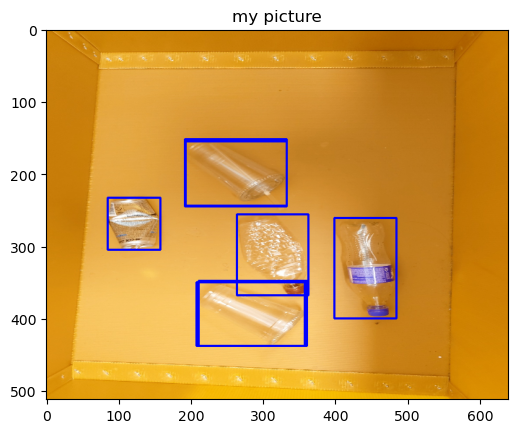

In [27]:
from matplotlib import pyplot as plt

plt.imshow(image)
plt.title('my picture')
plt.show()